### TRAINING SEED (MANUAL LABELED) DATA

In [5]:
import sys
!"{sys.executable}" -m pip install --force-reinstall scikit-learn transformers torch tqdm sastrawi

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached transformers-4.57.3-py3-none-any.whl.metadata (43 kB)
  Using cached torch-2.9.1-cp313-cp313-win_amd64.whl.metadata (30 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached Sastrawi-1.0.1-py2.py3-none-any.whl.metadata (909 bytes)
  Using cached scipy-1.16.3-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached filelock-3.20.2-py3-none-any.whl.metadata (2.1 kB)
  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached regex-2025.11.3-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached tokenizers-0.22.2-

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
selenium 4.35.0 requires typing_extensions~=4.14.0, but you have typing-extensions 4.15.0 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# =========================
# Core
# =========================
import os
import re
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple

# =========================
# Data / Numeric
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization (optional)
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Sklearn (split + metrics)
# =========================
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support
)

# =========================
# PyTorch
# =========================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# =========================
# Hugging Face Transformers (IndoBERT)
# =========================
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)

# =========================
# (Optional) Sastrawi
# =========================
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# =========================
# (Optional) Progress bar
# =========================
from tqdm.auto import tqdm

TRAIN_DATA_PATH = '../../data/data_berita/train_data/'


In [12]:
df1 = pd.read_csv(f"{TRAIN_DATA_PATH}/cnbc_train_data.csv")
df2 = pd.read_csv(f"{TRAIN_DATA_PATH}/detik_train_data.csv")
df3 = pd.read_csv(f"{TRAIN_DATA_PATH}/kompas_train_data.csv")

print(df1.columns)
display(df1.head())
print(df3.columns)
display(df2.head())
print(df3.columns)
display(df3.head())

Index(['date', 'title', 'content', 'article_id', 'text', 'label'], dtype='object')


,date,title,content,article_id,text,label
0,2019-09-11,menko luhut jokowi tak mungkin asal pilih ment...,presiden joko widodo jokowi menegaskan susuan ...,CNBC_00008,menko luhut jokowi tak mungkin asal pilih ment...,0
1,2019-09-24,ini siasat lobi-lobi boris saat brexit makin u...,kurang dari 40 hari jelang tenggat waktu inggr...,CNBC_00012,ini siasat lobi-lobi boris saat brexit makin u...,0
2,2019-10-06,"menterinya terbanyak se-asean, kabinet ri baka...","negara tetangga kita, di asia tenggara. berdas...",CNBC_00017,"menterinya terbanyak se-asean, kabinet ri baka...",0
3,2019-10-16,akankah gerindra masuk koalisi jokowi?,partai gerindra menggelar rapat kerja nasional...,CNBC_00023,akankah gerindra masuk koalisi jokowi?. partai...,0
4,2019-10-16,"kubu prabowo masuk koalisi jokowi, berkah atau...",orang yang memang sangat kredibel seperti sri ...,CNBC_00026,"kubu prabowo masuk koalisi jokowi, berkah atau...",1


Index(['date', 'title', 'content', 'label', 'article_id', 'text'], dtype='object')


,date,title,content,text,label,article_id
0,2023-12-20,mendagri copot pj bupati kampar karena tak net...,menteri dalam negeri mendagri tito karnavian m...,mendagri copot pj bupati kampar karena tak net...,-1,DETIK_7302
1,2025-06-20,waka mpr nilai keputusan prabowo absen di g7 j...,"wakil ketua mpr dari fraksi pan, eddy soeparno...",waka mpr nilai keputusan prabowo absen di g7 j...,0,DETIK_1543
2,2024-02-14,"setelah nyoblos, ahy bakal merapat ke istora s...",tim kampanye nasional tkn prabowo-gibran bakal...,"setelah nyoblos, ahy bakal merapat ke istora s...",0,DETIK_6055
3,2024-06-05,obrolan jk dan baradar jika diizinkan saya ban...,wakil perdana menteri 1 afghanistan mullah abd...,obrolan jk dan baradar jika diizinkan saya ban...,0,DETIK_4993
4,2023-10-31,golkar masih lobi khofifah gabung tkn prabowo-...,sekjen partai golkar lodewijk f paulus berbica...,golkar masih lobi khofifah gabung tkn prabowo-...,0,DETIK_8269


Index(['date', 'title', 'content', 'label', 'article_id', 'text'], dtype='object')


,date,title,content,label,article_id,text
0,2022-01-23,polemik arteria dahlan jadi pembelajaran kader...,sekretaris jenderal pdi-p hasto kristiyanto m...,0,KOMPAS_9963,polemik arteria dahlan jadi pembelajaran kader...
1,2022-01-23,"hut ke-75 megawati, pramono anung politik ibu ...",mantan sekretaris jenderal pdi perjuangan pra...,0,KOMPAS_9962,"hut ke-75 megawati, pramono anung politik ibu ..."
2,2022-01-24,pengamat tebak pesan anies ke giring kalau sum...,direktur eksekutif parameter politik indonesi...,0,KOMPAS_9956,pengamat tebak pesan anies ke giring kalau sum...
3,2022-01-24,update 20.867 kasus aktif covid-19 di indonesia,pemerintah menyampaikan terdapat 20.867 kasus...,-1,KOMPAS_9945,update 20.867 kasus aktif covid-19 di indonesi...
4,2022-01-25,update 25 januari 7.483 kasus suspek covid-19 ...,"pemerintah mencatat, hingga selasa 25 1 2022 ...",-1,KOMPAS_9936,update 25 januari 7.483 kasus suspek covid-19 ...


### BISMILLAH KITA MULAI TRAINING

In [13]:
SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [16]:
# gabungin data
df_seed = pd.concat(
    [
        df1[["date", "title", "content", "article_id", "text", "label"]],
        df2[["date", "title", "content", "article_id", "text", "label"]],
        df3[["date", "title", "content", "article_id", "text", "label"]],
    ],
    axis=0,
    ignore_index=True
)

print(df_seed.shape)
df_seed.head()


(2599, 6)


,date,title,content,article_id,text,label
0,2019-09-11,menko luhut jokowi tak mungkin asal pilih ment...,presiden joko widodo jokowi menegaskan susuan ...,CNBC_00008,menko luhut jokowi tak mungkin asal pilih ment...,0
1,2019-09-24,ini siasat lobi-lobi boris saat brexit makin u...,kurang dari 40 hari jelang tenggat waktu inggr...,CNBC_00012,ini siasat lobi-lobi boris saat brexit makin u...,0
2,2019-10-06,"menterinya terbanyak se-asean, kabinet ri baka...","negara tetangga kita, di asia tenggara. berdas...",CNBC_00017,"menterinya terbanyak se-asean, kabinet ri baka...",0
3,2019-10-16,akankah gerindra masuk koalisi jokowi?,partai gerindra menggelar rapat kerja nasional...,CNBC_00023,akankah gerindra masuk koalisi jokowi?. partai...,0
4,2019-10-16,"kubu prabowo masuk koalisi jokowi, berkah atau...",orang yang memang sangat kredibel seperti sri ...,CNBC_00026,"kubu prabowo masuk koalisi jokowi, berkah atau...",1


In [18]:
#validasi data abis digabungin
assert set(df_seed["label"].unique()).issubset({-1, 0, 1})

# cek null
df_seed.isna().sum()


date          0
title         0
content       0
article_id    0
text          0
label         0
dtype: int64

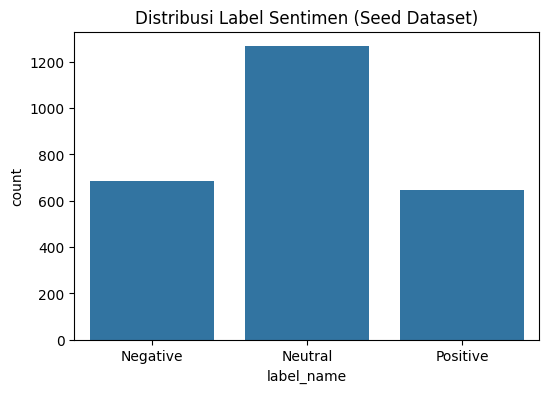

In [20]:
#EDA tipis tipis rekans

#cek hasil labeling manual (label distribution)
label_map = {-1: "Negative", 0: "Neutral", 1: "Positive"}
df_seed["label_name"] = df_seed["label"].map(label_map)

plt.figure(figsize=(6,4))
sns.countplot(data=df_seed, x="label_name", order=["Negative", "Neutral", "Positive"])
plt.title("Distribusi Label Sentimen (Seed Dataset)")
plt.show()


Distribusi label diatas nunjukin kalo sentimen dominan netral, yang artinya karakteristik alami dari berita politik bersifat informatif. Dari data ini juga dapat disimpulkan distribusi kelas masih relatif seimbang karena ngga ada class (netral/positif/negatif) yang jumlahnya under 10% jadii ga perlu imbalancing/oversampling data tambahan.

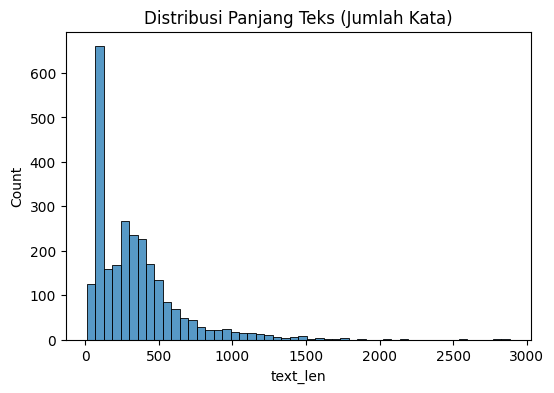

count    2599.000000
mean      343.167372
std       297.040823
min        12.000000
25%       111.000000
50%       282.000000
75%       448.000000
max      2882.000000
Name: text_len, dtype: float64

In [21]:
# cek text lennya
df_seed["text_len"] = df_seed["text"].str.split().apply(len)

plt.figure(figsize=(6,4))
sns.histplot(df_seed["text_len"], bins=50)
plt.title("Distribusi Panjang Teks (Jumlah Kata)")
plt.show()

df_seed["text_len"].describe()


Dari data length, kita bisa liat kalo si data data ini tu mostly di 100-500 kata, ada outlier di 2500 kata. Ini data sesuai dengan karakter data berita, leadny pendek, content panjang. outlier hrusnya ga ngerusak indobert, dia bisa self truncation. dari data ini ngambil max length 256 buat tokenize masih ok, karena perlu nyeimbangin konteks ama computationny. boleh ke 512 kalo GPU kita kuat

## MASUK TRAINING YGY

In [23]:
# train & validation data split
train_df, val_df = train_test_split(
    df_seed,
    test_size=0.2,
    stratify=df_seed["label"],
    random_state=SEED
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)


Train: (2079, 8)
Val: (520, 8)


In [24]:
#label remapping
label_to_id = {-1: 0, 0: 1, 1: 2}
id_to_label = {0: "negative", 1: "neutral", 2: "positive"}

train_df["label_id"] = train_df["label"].map(label_to_id)
val_df["label_id"] = val_df["label"].map(label_to_id)


In [25]:
#tokenizer indobert
MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

d:\File\Private\OneDrive - Bina Nusantara\Kuliah\s k r i p s i s\code\skripsis\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Nick Mathew\.cache\huggingface\hub\models--indobenchmark--indobert-base-p1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
#dataset class
class NewsSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding=False,
            max_length=self.max_length
        )
        enc["labels"] = self.labels[idx]
        return enc


In [ ]:
# dataset obj
train_dataset = NewsSentimentDataset(
    train_df["text"],
    train_df["label_id"],
    tokenizer
)

val_dataset = NewsSentimentDataset(
    val_df["text"],
    val_df["label_id"],
    tokenizer
)


In [ ]:
# init model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id_to_label,
    label2id={v:k for k,v in id_to_label.items()}
)

model.to(device)


In [ ]:
# metric function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    
    return {
        "accuracy": (preds == labels).mean(),
        "macro_f1": classification_report(
            labels, preds, output_dict=True
        )["macro avg"]["f1-score"]
    }


In [ ]:
#training arg
training_args = TrainingArguments(
    output_dir="./indobert_sentiment",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    save_total_limit=2,
    report_to="none"
)


In [ ]:
#create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)


In [ ]:
#ini diaa, latihannnn
trainer.train()


In [ ]:
# evaluation model
preds = trainer.predict(val_dataset)
y_true = val_df["label_id"].values
y_pred = np.argmax(preds.predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=["negative", "neutral", "positive"]))


In [ ]:
# saving model
trainer.save_model("indobert_sentiment_news")
tokenizer.save_pretrained("indobert_sentiment_news")
